In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression, LinearRegression

def generate_research_data(n=2000, overlap_strength=1.0, base_seed=12345):
    # Deterministic seed per overlap strength
    seed = base_seed + int(1000 * overlap_strength)
    rng = np.random.default_rng(seed)

    # x is centered at 2 to break symmetry and expose OLS bias
    x = rng.normal(2, 1, n)

    # Treatment assignment (Propensity)
    logits = overlap_strength * x + rng.normal(0, 0.5, n)
    prob_t = 1 / (1 + np.exp(-logits))
    t = rng.binomial(1, prob_t)

    # Outcome with non-linearity (x^2)
    # True ATE = 5.0
    y = (
        10
        + 5.0 * t
        + 3.0 * x
        + 1.5 * x**2
        + rng.normal(0, 1, n)
    )

    return pd.DataFrame({"x": x, "t": t, "y": y})


In [9]:
def get_all_estimates(df):
    # 1. Propensity Score
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    df['ps'] = np.clip(lr.predict_proba(df[['x']])[:, 1], 0.001, 0.999)
    
    # 2. Outcome Models
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])
    df['mu1'], df['mu0'] = m1.predict(df[['x']]), m0.predict(df[['x']])
    
    # --- OLS ---
    ols_ate = smf.ols('y ~ t + x', data=df).fit().params['t']
    
    # --- IPW (Hajek) ---
    w1_ipw, w0_ipw = df.t/df.ps, (1-df.t)/(1-df.ps)
    iptw_ate = (df.y*w1_ipw).sum()/w1_ipw.sum() - (df.y*w0_ipw).sum()/w0_ipw.sum()
    
    # --- AIPW (Doubly Robust) ---
    dr_ate = ((df.mu1 - df.mu0) + (df.t*(df.y-df.mu1)/df.ps) - ((1-df.t)*(df.y-df.mu0)/(1-df.ps))).mean()

    # --- ATO (Average Treatment Effect on the Overlap) ---
    w1_ato, w0_ato = df.t*(1-df.ps), (1-df.t)*df.ps
    ato_ate = (df.y*w1_ato).sum()/w1_ato.sum() - (df.y*w0_ato).sum()/w0_ato.sum()

    return {'OLS': ols_ate, 'IPW': iptw_ate, 'AIPW': dr_ate, 'ATO': ato_ate}

In [10]:
df_high = generate_research_data(n=2000, overlap_strength=1.0)
print(get_all_estimates(df_high))

{'OLS': 4.551636589995505, 'IPW': 5.670179602525124, 'AIPW': 5.349977431649366, 'ATO': 5.223246209271565}


In [11]:
df_high = generate_research_data(n=2000, overlap_strength=4.50)
print(get_all_estimates(df_high))

{'OLS': -2.0858162280098553, 'IPW': 10.611362538645157, 'AIPW': 10.181280706028879, 'ATO': 5.606595455437805}


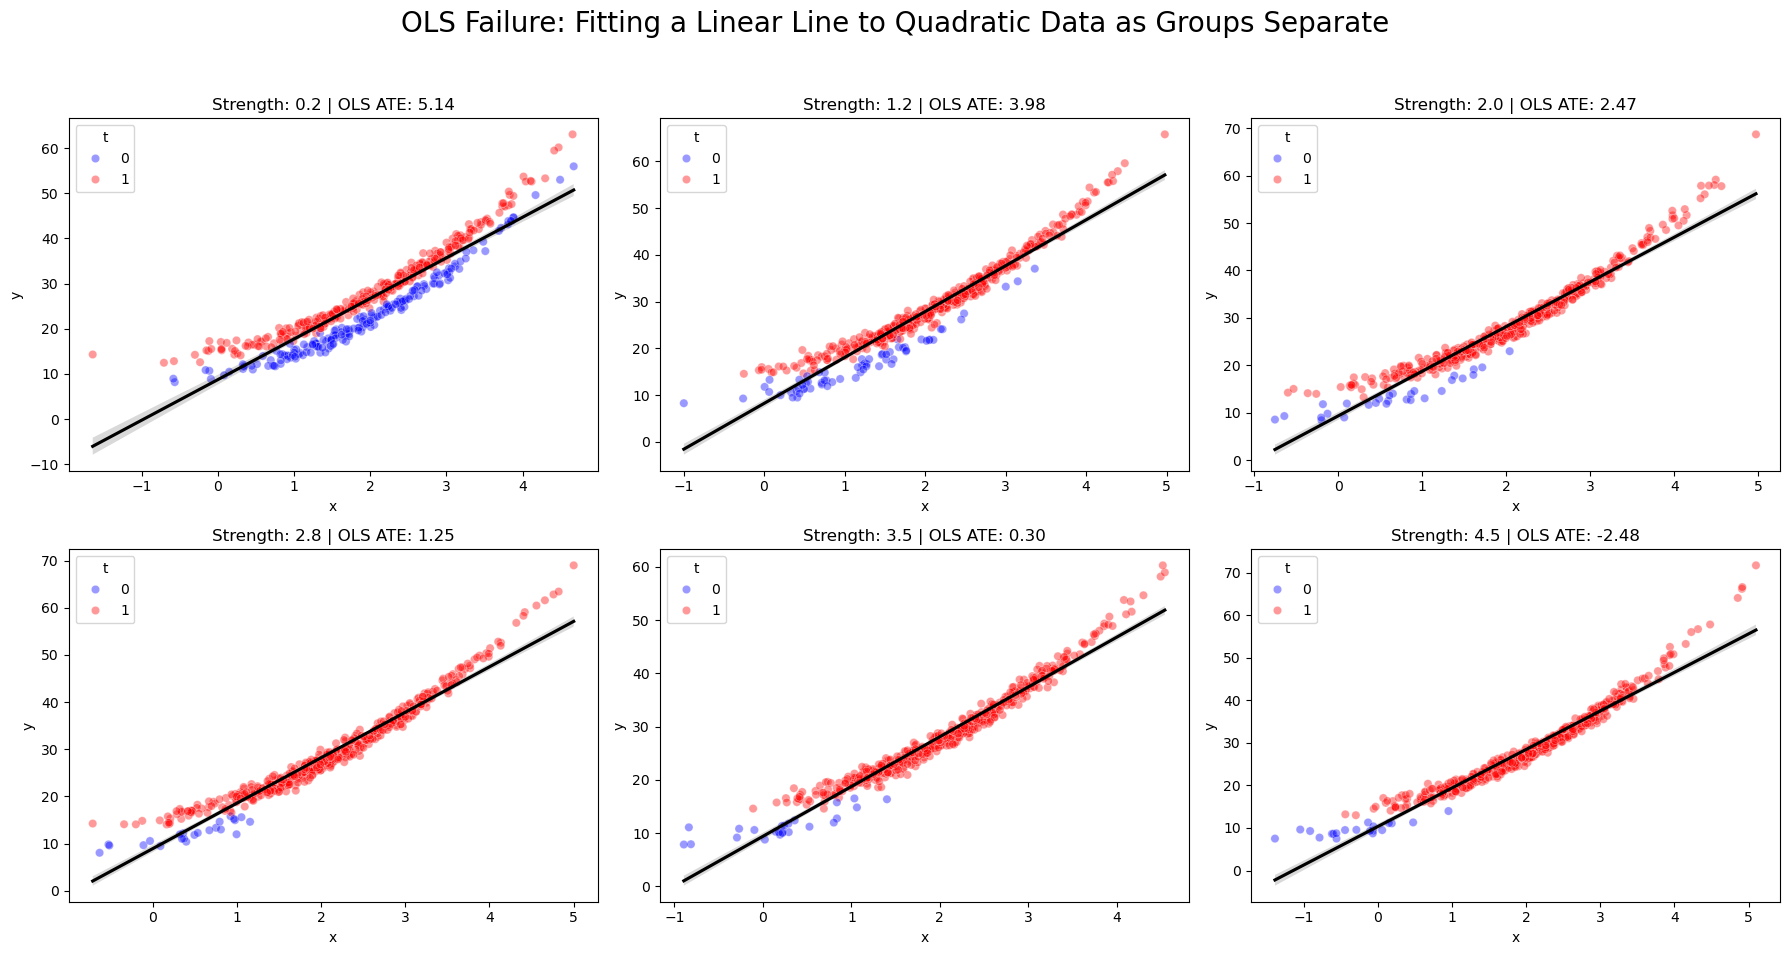

In [5]:
strengths = [0.2, 1.2, 2.0, 2.8, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)
    ate_val = smf.ols('y ~ t + x', data=df).fit().params['t']
    
    sns.scatterplot(data=df, x='x', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    sns.regplot(data=df, x='x', y='y', scatter=False, color='black', ax=axes[i])
    axes[i].set_title(f"Strength: {s} | OLS ATE: {ate_val:.2f}")

plt.suptitle("OLS Failure: Fitting a Linear Line to Quadratic Data as Groups Separate", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

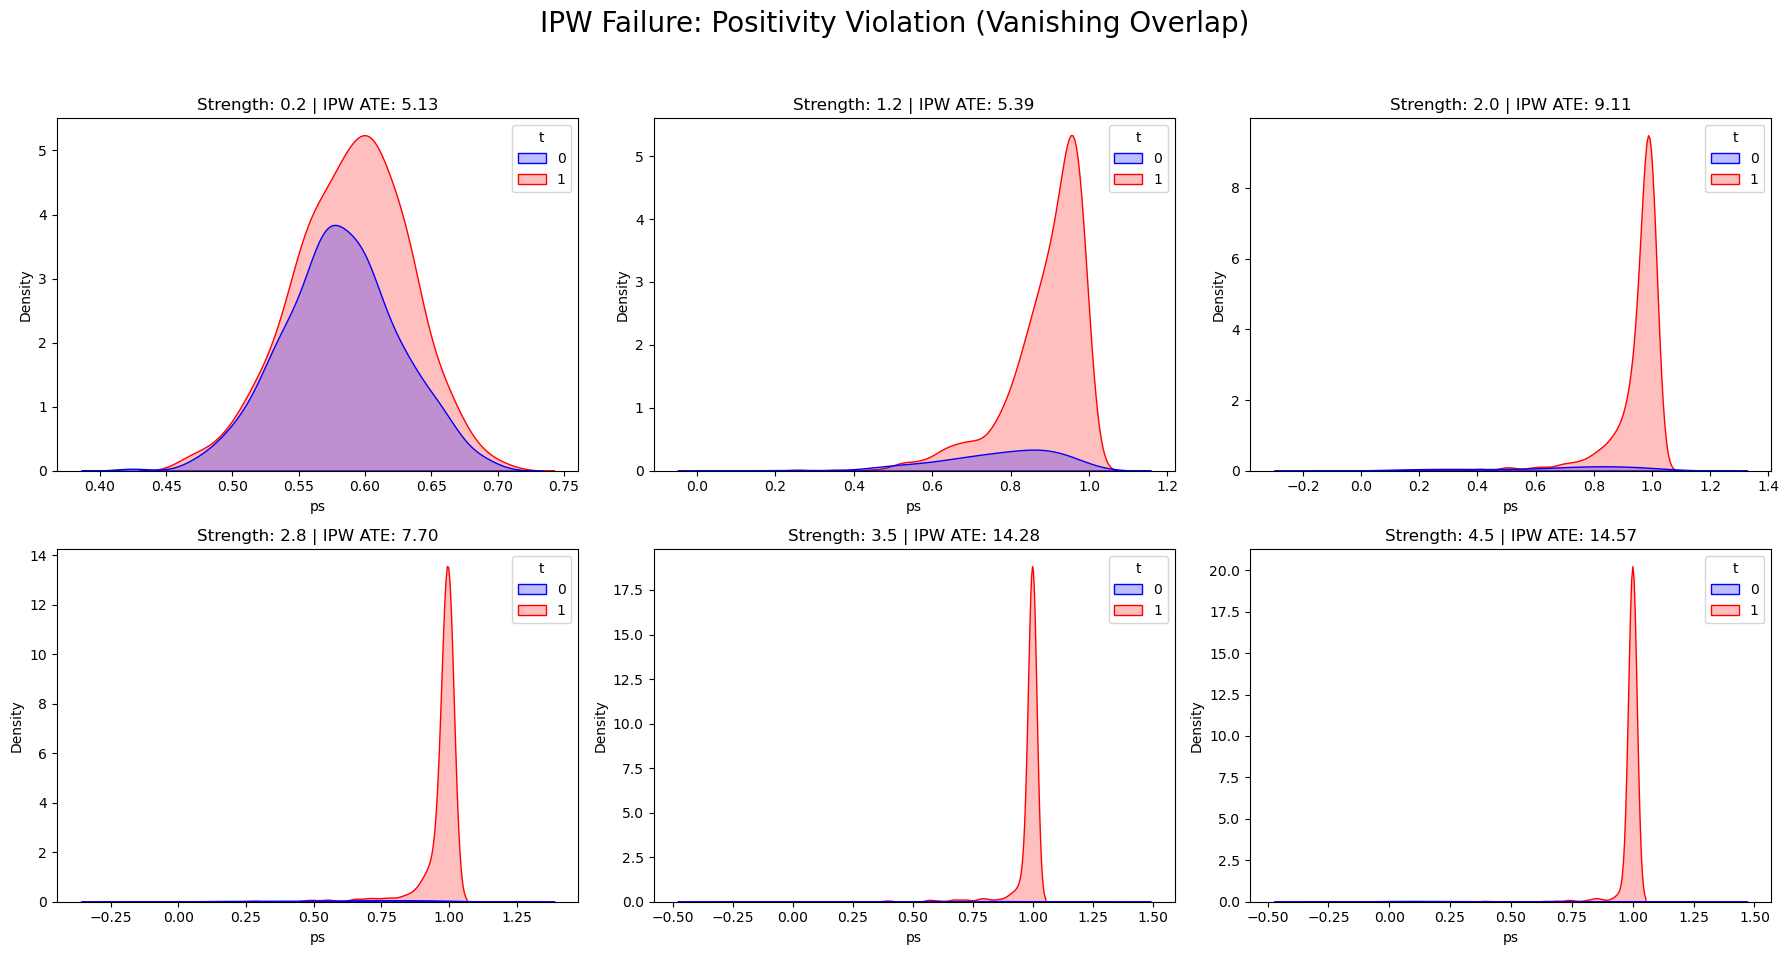

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, s in enumerate(strengths):
    df = generate_research_data(n=1000, overlap_strength=s)
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    df['ps'] = lr.predict_proba(df[['x']])[:, 1]
    
    sns.kdeplot(data=df, x='ps', hue='t', fill=True, ax=axes.flatten()[i], palette=['blue', 'red'])
    # Calculate IPTW ATE for title
    w1, w0 = df['t']/df['ps'], (1-df['t'])/(1-df['ps'])
    iptw_val = (df['y']*w1).sum()/w1.sum() - (df['y']*w0).sum()/w0.sum()
    axes.flatten()[i].set_title(f"Strength: {s} | IPW ATE: {iptw_val:.2f}")

plt.suptitle("IPW Failure: Positivity Violation (Vanishing Overlap)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

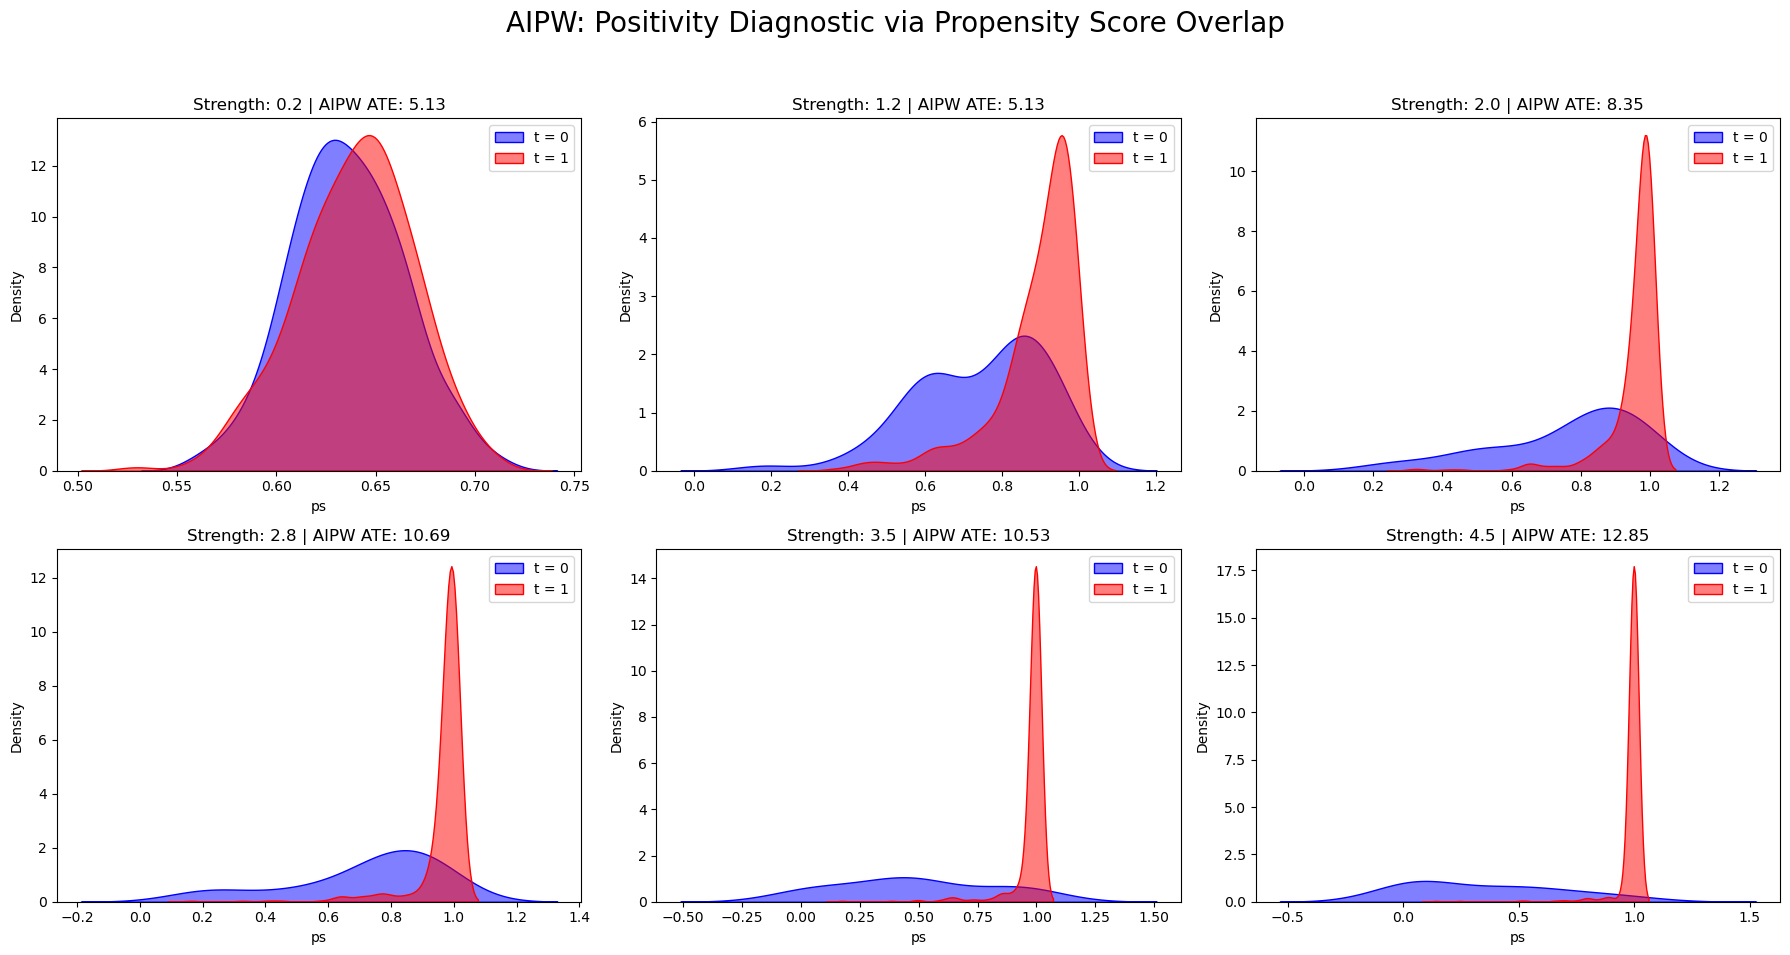

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)

    # --- Propensity model ---
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    ps = lr.predict_proba(df[['x']])[:, 1]
    ps_clip = np.clip(ps, 0.001, 0.999)

    # --- Outcome models ---
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])

    mu1 = m1.predict(df[['x']])
    mu0 = m0.predict(df[['x']])

    # --- AIPW estimator ---
    aipw_ate = (
        (mu1 - mu0)
        + df.t * (df.y - mu1) / ps_clip
        - (1 - df.t) * (df.y - mu0) / (1 - ps_clip)
    ).mean()

    # --- KDE of propensity scores (diagnostic) ---
    df_plot = df.copy()
    df_plot["ps"] = ps

    sns.kdeplot(
        data=df_plot[df_plot.t == 0],
        x="ps",
        fill=True,
        alpha=0.5,
        label="t = 0",
        color="blue",
        ax=axes[i]
    )

    sns.kdeplot(
        data=df_plot[df_plot.t == 1],
        x="ps",
        fill=True,
        alpha=0.5,
        label="t = 1",
        color="red",
        ax=axes[i]
    )

    axes[i].set_title(f"Strength: {s} | AIPW ATE: {aipw_ate:.2f}")
    axes[i].set_xlabel("ps")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle(
    "AIPW: Positivity Diagnostic via Propensity Score Overlap",
    fontsize=20
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


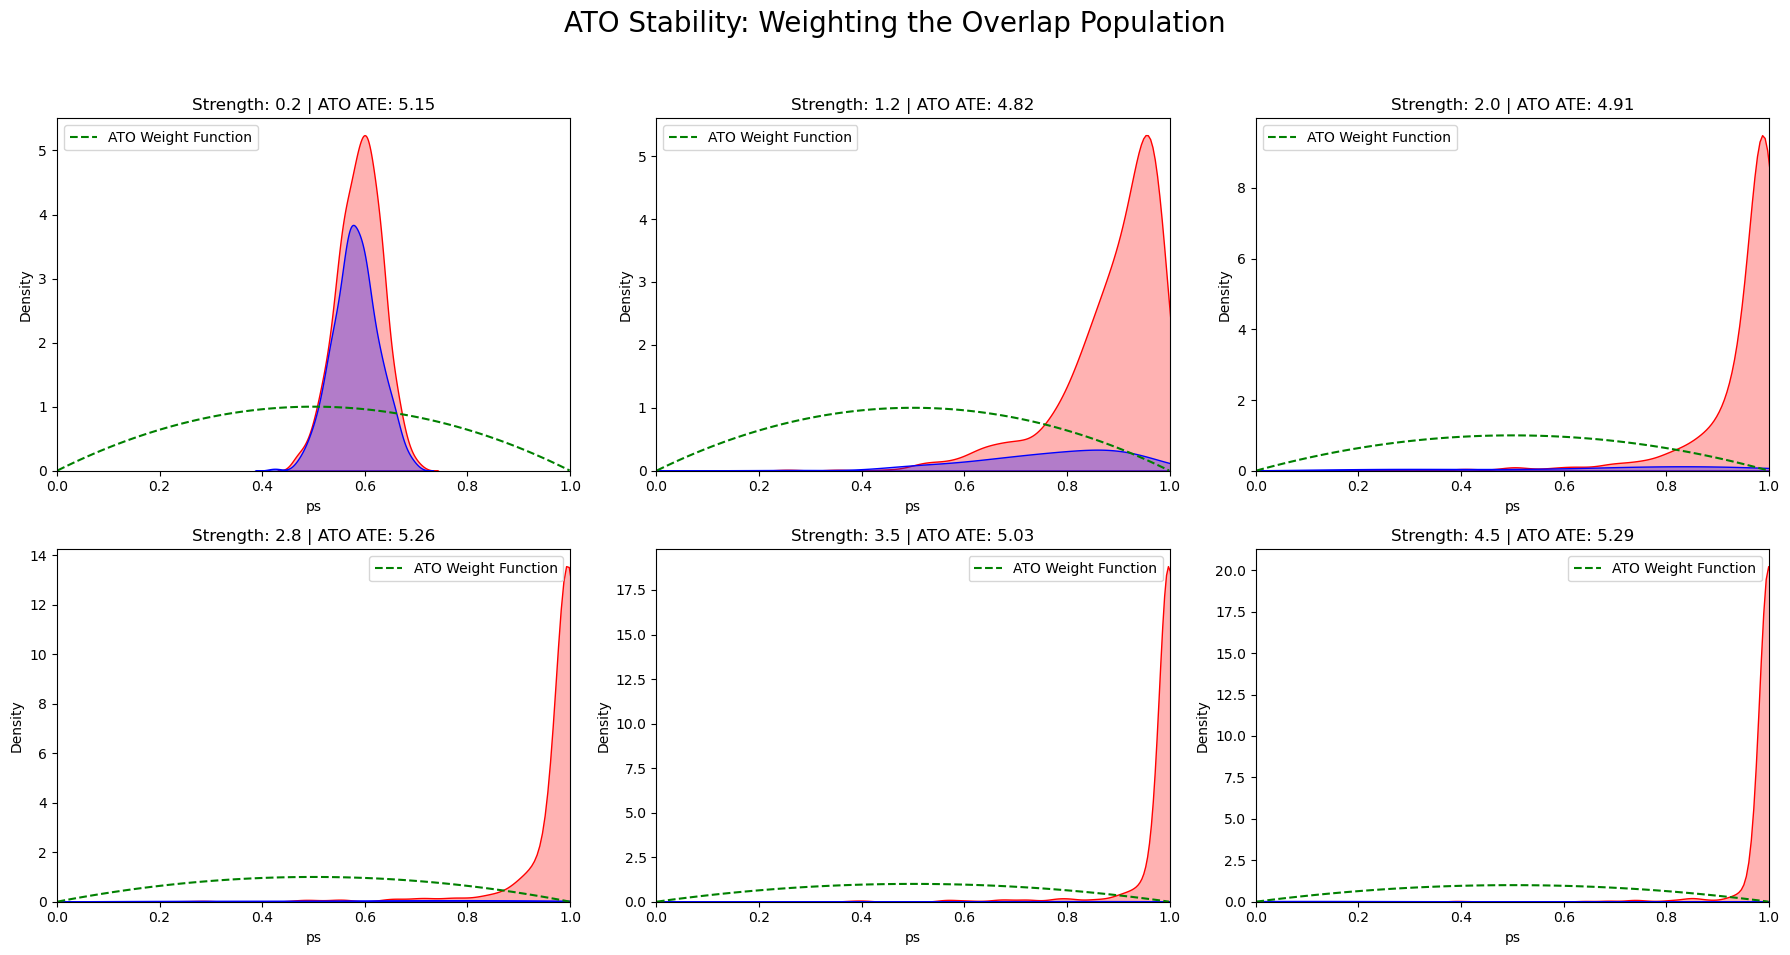

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=1000, overlap_strength=s)
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    df['ps'] = lr.predict_proba(df[['x']])[:, 1]
    
    # 1. Plot the Density of Treated vs Control
    sns.kdeplot(data=df, x='ps', hue='t', fill=True, ax=axes[i], palette=['blue', 'red'], alpha=0.3)
    
    # 2. Overlay the ATO Weighting Curve (The "Overlap" Weight)
    # This curve peaks at ps=0.5 and goes to 0 at ps=0 and ps=1
    ps_range = np.linspace(0.001, 0.999, 100)
    ato_weights_curve = 4 * ps_range * (1 - ps_range) # Scaled by 4 for visibility
    axes[i].plot(ps_range, ato_weights_curve, color='green', linestyle='--', label='ATO Weight Function')
    
    # 3. Calculate ATO ATE using Hajek Weights
    w1, w0 = df['t'] * (1 - df['ps']), (1 - df['t']) * df['ps']
    ato_val = (df['y'] * w1).sum() / w1.sum() - (df['y'] * w0).sum() / w0.sum()
    
    axes[i].set_title(f"Strength: {s} | ATO ATE: {ato_val:.2f}")
    axes[i].set_xlim(0, 1)
    axes[i].legend()

plt.suptitle("ATO Stability: Weighting the Overlap Population", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()